In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [ ]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1

# ── Shuffle method ────────────────────────────────────────────────────────────
# 'label_shift'  : cyclically shift task_anchored_labels by a random number of
#                  trials drawn uniformly from [20%, 80%] of total trials.
#                  Fast — no spectral analysis required.
# 'field_shuffle': spatially relocate firing fields in the rate map, then
#                  re-derive task_anchored_labels via spectral analysis.
SHUFFLE_METHOD = 'label_shift'  # 'label_shift' | 'field_shuffle'

class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)


In [3]:
def load_cluster_locations(clusters, cells):
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

In [ ]:
import json

# ── Output accumulators ────────────────────────────────────────────────────────
gcs_    = pd.DataFrame()
ngs_    = pd.DataFrame()
others_ = pd.DataFrame()
all_    = pd.DataFrame()

cache_dir = '/Users/harryclark/Documents/spatial-manifolds/data/behavioural_influence_cache'
os.makedirs(cache_dir, exist_ok=True)

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

def _safe_read_csv(path):
    """Read a CSV, returning an empty DataFrame for empty/missing files."""
    try:
        return pd.read_csv(path)
    except (pd.errors.EmptyDataError, FileNotFoundError):
        return pd.DataFrame()

def _percentage_hits(trial_types, trial_performances, task_anchored_labels, trial_type, task_label):
    mask  = (trial_types == trial_type) & (task_anchored_labels == task_label)
    hits  = np.sum(trial_performances[mask] == 'hit')
    total = np.sum(mask)
    return 100 * hits / total if total > 0 else np.nan

for mouse, days in mouse_days.items():
    for day in days:

        # ── Cache check ───────────────────────────────────────────────────────
        cache_file = os.path.join(cache_dir, f'M{mouse}_D{day:02d}.csv')

        if os.path.exists(cache_file):
            print(f"M{mouse} D{day:02d}: loading from cache.")
            df = _safe_read_csv(cache_file)
            if len(df) > 0 and 'cell_identity' in df.columns:
                gcs_    = pd.concat([gcs_,    df[df.cell_identity == 'GC']], ignore_index=True)
                ngs_    = pd.concat([ngs_,    df[df.cell_identity.isin(['NGS-ramp', 'NGS-nonramp'])]], ignore_index=True)
                others_ = pd.concat([others_, df[df.cell_identity == 'NS']], ignore_index=True)
                all_    = pd.concat([all_,    df], ignore_index=True)
            continue

        print(f"Processing M{mouse} D{day:02}...")

        gcs, ngs, all_cells = classify_cells_both_sessions(
            mouse, day, percentile_threshold=95, source_path=None, verbose=False,
        )
        others = all_cells[~all_cells.index.isin(gcs.index) & ~all_cells.index.isin(ngs.index)]

        gcs    = gcs.copy();    gcs['cell_type']    = 'GC'
        ngs    = ngs.copy();    ngs['cell_type']    = 'NG'
        others = others.copy(); others['cell_type'] = 'Other'

        for cells in [gcs, ngs, others]:
            cells['mouse'] = mouse
            cells['day']   = day

        # determine which NGS cluster_ids are also VR ramp cells
        ramp_ids = set()
        try:
            rc, _, _ = cell_classification_vr(mouse, day)
            if len(rc) > 0:
                ramp_ids = set(int(x) for x in rc.cluster_id.values)
        except Exception as e:
            print(f"  VR ramp classification failed for M{mouse} D{day:02}: {e}")

        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False, apply_guassian_filter=False)

        last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
        ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')
        speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units='ms', ep=ep))
        dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep) - ((beh['trial_number'][0]-1)*tl))
        pos_in_time = dt_in_time % tl
        trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]

        if np.any(np.isnan(pos_in_time)):
            dt_in_time = np.array(pd.Series(dt_in_time).ffill().bfill())
            pos_in_time = dt_in_time % tl
            trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]
        if np.any(np.isnan(speed_in_time)):
            speed_in_time = np.array(pd.Series(speed_in_time).ffill().bfill())

        last_trial         = int(last_ephys_bin / (tl / bs))
        trial_types        = beh['trials'].type[:last_trial].values
        trial_performances = beh['trials'].performance[:last_trial].values
        peak_indices       = [12, 28, 44, 60, 76]

        # ── Unified cell loop ─────────────────────────────────────────────────
        combined = pd.concat([gcs, ngs, others], ignore_index=True)

        for idx in range(len(combined)):
            example_cluster_id = combined.loc[idx, 'cluster_id']
            cell_type          = combined.loc[idx, 'cell_type']
            print(f"\nMouse: {mouse}, Day: {day}, Cluster: {example_cluster_id} ({cell_type})")

            if example_cluster_id not in tcs:
                continue

            tcs_to_use = {example_cluster_id: tcs[example_cluster_id]}
            tcs_to_use[1000] = tcs_to_use[example_cluster_id].copy()
            tcs_to_use[1000]               += np.random.normal(0.0, 0.001, size=tcs_to_use[1000].shape)
            tcs_to_use[example_cluster_id] += np.random.normal(0.0, 0.001, size=tcs_to_use[example_cluster_id].shape)

            try:
                results      = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3]
                S            = spectrograms.mean(0)
                max_peaks    = np.argmax(S, axis=0)
                labels       = np.isin(max_peaks, peak_indices).astype(int)
            except Exception as e:
                print(f"  spectral_analysis failed: {e}")
                continue

            tc = tcs[example_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            task_anchored_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl)

            combined.loc[idx, 'pct_b_1']              = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'b',  1)
            combined.loc[idx, 'pct_nb_1']             = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'nb', 1)
            combined.loc[idx, 'pct_b_0']              = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'b',  0)
            combined.loc[idx, 'pct_nb_0']             = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'nb', 0)
            combined.loc[idx, 'task_anchored_labels'] = json.dumps(task_anchored_labels.tolist())

        # Re-split by cell_type for cell_identity assignment
        gcs    = combined[combined.cell_type == 'GC'].copy().reset_index(drop=True)
        ngs    = combined[combined.cell_type == 'NG'].copy().reset_index(drop=True)
        others = combined[combined.cell_type == 'Other'].copy().reset_index(drop=True)

        # ── Assign cell_identity, save unified cache, accumulate ──────────────
        gcs['cell_identity']    = 'GC'
        gcs['shuffled']         = False
        ngs['cell_identity']    = ngs.cluster_id.apply(
            lambda cid: 'NGS-ramp' if int(cid) in ramp_ids else 'NGS-nonramp'
        )
        ngs['shuffled']         = False
        others['cell_identity'] = 'NS'
        others['shuffled']      = False

        session_df = pd.concat([gcs, ngs, others], ignore_index=True)
        session_df.to_csv(cache_file, index=False)
        print(f"  M{mouse} D{day:02d}: cached to {cache_dir}")

        gcs_    = pd.concat([gcs_,    gcs],        ignore_index=True)
        ngs_    = pd.concat([ngs_,    ngs],        ignore_index=True)
        others_ = pd.concat([others_, others],     ignore_index=True)
        all_    = pd.concat([all_,    session_df], ignore_index=True)

print(f'there are this many cells at the moment, {len(all_)}')
print(f'there are this many gcs at the moment, {len(gcs_)}')
print(f'there are this many ngs at the moment, {len(ngs_)}')
print(f'there are this many others at the moment, {len(others_)}')


M20 D14: loading from cache.
M20 D15: loading from cache.
M20 D16: loading from cache.
M20 D17: loading from cache.
M20 D18: loading from cache.
M20 D19: loading from cache.
M20 D20: loading from cache.
M20 D21: loading from cache.
M20 D22: loading from cache.
M20 D23: loading from cache.
M20 D24: loading from cache.
M20 D25: loading from cache.
M20 D26: loading from cache.
M21 D15: loading from cache.
M21 D16: loading from cache.
M21 D17: loading from cache.
M21 D18: loading from cache.
M21 D19: loading from cache.
M21 D20: loading from cache.
M21 D21: loading from cache.
M21 D22: loading from cache.
M21 D23: loading from cache.
M21 D24: loading from cache.
M21 D25: loading from cache.
M21 D26: loading from cache.
M22 D33: loading from cache.
M22 D34: loading from cache.
M22 D35: loading from cache.
M22 D36: loading from cache.
M22 D37: loading from cache.
M22 D38: loading from cache.
M22 D39: loading from cache.
M22 D40: loading from cache.
M22 D41: loading from cache.
M25 D16: loadi

In [5]:
# NGS sub-classification is already encoded in cell_identity from the main loop.
ngs_ramp_    = ngs_[ngs_.cell_identity == 'NGS-ramp'].reset_index(drop=True)
ngs_nonramp_ = ngs_[ngs_.cell_identity == 'NGS-nonramp'].reset_index(drop=True)

print(f'{len(ngs_ramp_)} NGS-ramp cells  ({len(ngs_)} NGS total)')
print(f'{len(ngs_nonramp_)} NGS-non-ramp cells')


1513 NGS-ramp cells  (6014 NGS total, 2944 unique VR ramp cells)
4501 NGS-non-ramp cells
ramp classes present: n/a


## Field Shuffle Control Group

To generate a shuffled control group, a **field shuffle** procedure is applied to every cell's spatial tuning curve before the task-anchoring analysis is run. This creates a null distribution in which the within-field spatial structure of firing is preserved but the locations of fields along the track are randomised.

### How the field shuffle works

1. **Flattened session map.**  
   The cell's full tuning-curve array — shape `(n_trials, n_pos_bins)` — is flattened into a single 1-D sequence of length `n_trials × n_pos_bins`. This unravelled trace represents the firing rate across every trial concatenated end-to-end.

2. **Smoothed map for peak detection.**  
   The flattened firing-rate trace is convolved with a 1-D Gaussian kernel (SD = 4 cm, converted to bins) to suppress noise.

3. **Peak and trough identification.**  
   Peaks are detected in the smoothed flattened map using `scipy.signal.find_peaks` with a minimum inter-peak distance of 20 cm (in bins). Each peak is associated with its two adjacent troughs, which define the left and right boundary of a firing **field**.

4. **Field array construction.**  
   Each bin in the flattened trace is assigned an integer field label (1, 2, …, *N*) if it falls inside a field, or 0 if it is in an inter-field region.

5. **Random field relocation.**  
   Fields are placed one by one in a random order into an output array of the same length. For each field, its peak bin is placed at a randomly chosen empty position, and the bins to the left and right (up to the original field extent) are filled in sequence, wrapping around if necessary.

6. **Filling inter-field gaps.**  
   Bins that do not belong to any field in the original trace are randomly redistributed among the remaining unfilled positions.

7. **Reshape.**  
   The shuffled 1-D array is reshaped back to `(n_trials, n_pos_bins)` and passed through the same spectral-analysis → task-anchoring → percentage-hits pipeline as the real cells.

Results are stored in a `shuffled_` DataFrame for comparison alongside the GC, NGS-ramp, NGS-non-ramp, and NS groups.

In [6]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d


# ── Helper: find the two adjacent troughs around a peak ──────────────────────
def _find_troughs(fr, peak_idx):
    """Walk left and right from peak_idx to find the nearest local minima."""
    lo = peak_idx
    for i in range(peak_idx - 1, -1, -1):
        if np.isnan(fr[i]):
            continue
        if fr[i] < fr[lo]:
            lo = i
        elif fr[i] > fr[lo]:
            break
    hi = peak_idx
    for i in range(peak_idx + 1, len(fr)):
        if np.isnan(fr[i]):
            continue
        if fr[i] < fr[hi]:
            hi = i
        elif fr[i] > fr[hi]:
            break
    return lo, hi


# ── Helper: build field-label array (0 = inter-field, 1..N = field index) ────
def _make_field_array(n_bins, peak_boundaries):
    """peak_boundaries: list of (lo, hi) tuples, one per detected field."""
    arr = np.zeros(n_bins, dtype=np.int64)
    for k, (lo, hi) in enumerate(peak_boundaries):
        arr[lo:hi + 1] = k + 1
    return arr


# ── Helper: fill shuffled rate map ───────────────────────────────────────────
def _fill_rate_map(fr_original, peaks_i, field_array, peak_fill_order):
    """
    Randomly relocate each firing field in `fr_original`.

    Parameters
    ----------
    fr_original : 1-D np.ndarray  – NaN-cleaned firing rate
    peaks_i     : 1-D array of peak bin indices
    field_array : 1-D int array   – field label per bin (0 = inter-field)
    peak_fill_order : 1-D int array – order in which to place fields (1-indexed)

    Returns
    -------
    fr : 1-D np.ndarray – shuffled firing rate map (same length as fr_original)
    """
    fr_orig = fr_original.copy()
    fr_orig[np.isnan(fr_orig)] = 0.0

    n = len(fr_orig)
    fr = np.full(n, np.nan)

    used_src = []
    used_dst = []

    for field_idx in peak_fill_order:
        peak_i = peaks_i[field_idx - 1]
        field_bins = np.where(field_array == field_idx)[0]
        if len(field_bins) == 0:
            continue
        left_ext  = peak_i - field_bins[0]
        right_ext = field_bins[-1] - peak_i

        # pick a random empty slot for the peak
        empty = np.where(np.isnan(fr))[0]
        if len(empty) == 0:
            break
        rand_peak = empty[np.random.randint(len(empty))]
        fr[rand_peak] = fr_orig[peak_i]
        used_dst.append(rand_peak)
        used_src.append(peak_i)

        # fill left arm
        for d in range(1, left_ext + 1):
            dst = (rand_peak - d) % n
            src = max(peak_i - d, 0)
            while not np.isnan(fr[dst]):
                dst = (dst - 1) % n
            fr[dst] = fr_orig[src]
            used_dst.append(dst)
            used_src.append(src)

        # fill right arm
        for d in range(1, right_ext + 1):
            dst = (rand_peak + d) % n
            src = min(peak_i + d, n - 1)
            while not np.isnan(fr[dst]):
                dst = (dst + 1) % n
            fr[dst] = fr_orig[src]
            used_dst.append(dst)
            used_src.append(src)

    # fill remaining inter-field bins randomly
    unfilled_dst = np.array(sorted(set(range(n)) - set(used_dst)))
    unused_src   = np.array(sorted(set(range(n)) - set(used_src)))
    np.random.shuffle(unused_src)
    for i, dst in enumerate(unfilled_dst):
        fr[dst] = fr_orig[unused_src[i % len(unused_src)]]

    return fr


# ── Main field-shuffle function ───────────────────────────────────────────────
def field_shuffle_tc(tc_1d, n_pos_bins, vr_track_length_cm=tl,
                     gauss_sigma_cm=4.0, min_peak_distance_cm=20):
    """
    Apply a field shuffle to a linearised tuning-curve array.

    `tcs[cell]` from `compute_vr_tcs` is a 1-D array of shape
    (n_trials * n_pos_bins,) — all per-trial firing rates concatenated.
    Fields are detected on a smoothed version of this array, then randomly
    relocated within the same space.

    Parameters
    ----------
    tc_1d       : np.ndarray, shape (n_trials * n_pos_bins,)
    n_pos_bins  : int   – number of position bins per trial (= tl / bs)
    vr_track_length_cm  : float – physical track length in cm (default 200)
    gauss_sigma_cm      : float – SD of Gaussian for peak detection, in cm
    min_peak_distance_cm : float – minimum inter-peak distance, in cm

    Returns
    -------
    tc_shuffled : np.ndarray, shape (n_trials * n_pos_bins,) – same as input
    """
    flat_clean = np.nan_to_num(tc_1d, nan=0.0).astype(float)

    # Use n_pos_bins (bins per trial) to convert cm-scale params to bins
    cm_per_bin    = vr_track_length_cm / n_pos_bins
    sigma_bins    = gauss_sigma_cm / cm_per_bin
    min_dist_bins = int(np.round(min_peak_distance_cm / cm_per_bin))

    # ── 1. Smooth for peak detection ─────────────────────────────────────────
    flat_smooth = gaussian_filter1d(flat_clean, sigma=sigma_bins)

    # ── 2. Detect peaks ───────────────────────────────────────────────────────
    peaks_i, _ = find_peaks(flat_smooth, distance=max(1, min_dist_bins))

    if len(peaks_i) == 0:
        # no fields found – fall back to a random cyclic shift
        shift = np.random.randint(0, len(flat_clean))
        return np.roll(flat_clean, shift)

    # ── 3. Build field boundaries from troughs ───────────────────────────────
    peak_boundaries = [_find_troughs(flat_smooth, p) for p in peaks_i]
    field_array     = _make_field_array(len(flat_clean), peak_boundaries)

    # ── 4. Randomly relocate fields ──────────────────────────────────────────
    peak_fill_order = np.arange(1, len(peaks_i) + 1)
    np.random.shuffle(peak_fill_order)

    return _fill_rate_map(flat_clean, peaks_i, field_array, peak_fill_order)


In [ ]:
# ── Build shuffle control group ───────────────────────────────────────────────
# Method is controlled by SHUFFLE_METHOD (set in the config cell).
#
# 'label_shift':
#   For each cell, cyclically shift its stored task_anchored_labels by a random
#   number of trials drawn uniformly from [20%, 80%] of total trials, then
#   recompute hit percentages. No spectral analysis needed.
#
# 'field_shuffle':
#   Spatially relocate firing fields in the rate map, re-run spectral analysis
#   to derive new task_anchored_labels, then compute hit percentages.
#
# Cache files are named by method so both can coexist on disk:
#   label_shift  → M{mouse}_D{day:02d}_shuffled_labelshift.csv
#   field_shuffle→ M{mouse}_D{day:02d}_shuffled_fieldshuffle.csv

_cache_suffix = {'label_shift': 'labelshift', 'field_shuffle': 'fieldshuffle'}[SHUFFLE_METHOD]

shuffled_  = pd.DataFrame()
n_pos_bins = int(tl / bs)

for mouse, days in mouse_days.items():
    for day in days:

        shuf_cache = os.path.join(cache_dir, f'M{mouse}_D{day:02d}_shuffled_{_cache_suffix}.csv')

        if os.path.exists(shuf_cache):
            print(f"M{mouse} D{day:02d}: loading {SHUFFLE_METHOD} shuffle from cache.")
            _shuf_cached = _safe_read_csv(shuf_cache)
            if len(_shuf_cached) > 0 and 'cell_identity' in _shuf_cached.columns:
                shuffled_ = pd.concat([shuffled_, _shuf_cached], ignore_index=True)
            continue

        # ── label_shift ───────────────────────────────────────────────────────
        if SHUFFLE_METHOD == 'label_shift':
            print(f"Computing label-shift shuffle M{mouse} D{day:02}...")

            session_df = all_[(all_.mouse == mouse) & (all_.day == day)].reset_index(drop=True)
            if len(session_df) == 0:
                print(f"  No cells in all_ for M{mouse} D{day:02d}, skipping.")
                continue

            try:
                _, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
                    mouse, day, apply_zscore=False, apply_guassian_filter=False
                )
            except Exception as e:
                print(f"  compute_vr_tcs failed: {e}")
                continue

            last_trial         = int(last_ephys_bin / (tl / bs))
            trial_types        = beh['trials'].type[:last_trial].values
            trial_performances = beh['trials'].performance[:last_trial].values

            session_rows = []
            for _, cell_row in session_df.iterrows():
                orig_json = cell_row.get('task_anchored_labels')
                if pd.isna(orig_json):
                    continue

                orig_labels = np.array(json.loads(orig_json))
                n_trials    = len(orig_labels)
                lo          = max(1, int(0.2 * n_trials))
                hi          = max(lo + 1, int(0.8 * n_trials))
                shift       = np.random.randint(lo, hi)
                shifted     = np.roll(orig_labels, shift)

                row_data = cell_row.to_dict()
                row_data['shuffled']             = True
                row_data['task_anchored_labels'] = json.dumps(shifted.tolist())
                row_data['pct_b_1']              = _percentage_hits(trial_types, trial_performances, shifted, 'b',  1)
                row_data['pct_nb_1']             = _percentage_hits(trial_types, trial_performances, shifted, 'nb', 1)
                row_data['pct_b_0']              = _percentage_hits(trial_types, trial_performances, shifted, 'b',  0)
                row_data['pct_nb_0']             = _percentage_hits(trial_types, trial_performances, shifted, 'nb', 0)
                session_rows.append(row_data)

            if session_rows:
                df_session = pd.DataFrame(session_rows)
                df_session.to_csv(shuf_cache, index=False)
                shuffled_ = pd.concat([shuffled_, df_session], ignore_index=True)
                print(f"  M{mouse} D{day:02d}: {len(df_session)} label-shift cells cached.")
            else:
                pd.DataFrame({'_empty': [1]}).to_csv(shuf_cache, index=False)

        # ── field_shuffle ─────────────────────────────────────────────────────
        elif SHUFFLE_METHOD == 'field_shuffle':
            print(f"Computing field-shuffle M{mouse} D{day:02}...")

            try:
                gcs, ngs, all_cells = classify_cells_both_sessions(
                    mouse, day, percentile_threshold=95, source_path=None, verbose=False,
                )
                others = all_cells[~all_cells.index.isin(gcs.index) & ~all_cells.index.isin(ngs.index)]
            except Exception as e:
                print(f"  classify_cells_both_sessions failed: {e}")
                continue

            ramp_ids_shuf = set()
            try:
                rc_shuf, _, _ = cell_classification_vr(mouse, day)
                if len(rc_shuf) > 0:
                    ramp_ids_shuf = set(int(x) for x in rc_shuf.cluster_id.values)
            except Exception as e:
                print(f"  VR ramp classification failed: {e}")

            cell_identity_map = {}
            for cid in gcs.cluster_id.values:
                cell_identity_map[int(cid)] = 'GC'
            for cid in ngs.cluster_id.values:
                cell_identity_map[int(cid)] = 'NGS-ramp' if int(cid) in ramp_ids_shuf else 'NGS-nonramp'
            for cid in others.cluster_id.values:
                cell_identity_map[int(cid)] = 'NS'

            all_cells_session        = all_cells.copy()
            all_cells_session['mouse'] = mouse
            all_cells_session['day']   = day

            try:
                tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                    mouse, day, apply_zscore=False, apply_guassian_filter=False
                )
            except Exception as e:
                print(f"  compute_vr_tcs failed: {e}")
                continue

            last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
            ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

            speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units='ms', ep=ep))
            dt_in_time = np.array(
                beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
                - ((beh['trial_number'][0] - 1) * tl)
            )
            pos_in_time          = dt_in_time % tl
            trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]

            if np.any(np.isnan(pos_in_time)):
                dt_in_time           = np.array(pd.Series(dt_in_time).ffill().bfill())
                pos_in_time          = dt_in_time % tl
                trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]
            if np.any(np.isnan(speed_in_time)):
                speed_in_time = np.array(pd.Series(speed_in_time).ffill().bfill())

            last_trial         = int(last_ephys_bin / (tl / bs))
            trial_types        = beh['trials'].type[:last_trial].values
            trial_performances = beh['trials'].performance[:last_trial].values
            peak_indices       = [12, 28, 44, 60, 76]
            session_rows       = []

            for _, cell_row in all_cells_session.iterrows():
                example_cluster_id = int(cell_row['cluster_id'])
                if example_cluster_id not in tcs:
                    continue

                tc_orig = tcs[example_cluster_id]
                try:
                    tc_shuf = field_shuffle_tc(tc_orig, n_pos_bins=n_pos_bins)
                except Exception as e:
                    print(f"  field_shuffle_tc failed for cluster {example_cluster_id}: {e}")
                    continue

                tcs_to_use = {example_cluster_id: tc_shuf.copy()}
                tcs_to_use[1000] = tc_shuf.copy()
                tcs_to_use[1000]               += np.random.normal(0.0, 0.001, size=tc_shuf.shape)
                tcs_to_use[example_cluster_id] += np.random.normal(0.0, 0.001, size=tc_shuf.shape)

                try:
                    results      = spectral_analysis(tcs_to_use, tl, bs=bs)
                    spectrograms = results[3]
                    S            = spectrograms.mean(0)
                    max_peaks    = np.argmax(S, axis=0)
                    labels       = np.isin(max_peaks, peak_indices).astype(int)
                except Exception as e:
                    print(f"  spectral_analysis failed for cluster {example_cluster_id}: {e}")
                    continue

                tc_flat = gaussian_filter(np.nan_to_num(tc_shuf).astype(np.float64), sigma=2.5)
                tc_flat = tc_flat[:last_ephys_bin]
                task_anchored_labels = get_kmeans_spatial_labels(tc_flat, labels, bs=bs, tl=tl)

                row_data = cell_row.to_dict()
                row_data['cell_identity']        = cell_identity_map.get(example_cluster_id, 'NS')
                row_data['shuffled']             = True
                row_data['task_anchored_labels'] = json.dumps(task_anchored_labels.tolist())
                row_data['pct_b_1']              = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'b',  1)
                row_data['pct_nb_1']             = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'nb', 1)
                row_data['pct_b_0']              = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'b',  0)
                row_data['pct_nb_0']             = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'nb', 0)
                session_rows.append(row_data)

            if session_rows:
                df_session = pd.DataFrame(session_rows)
                df_session.to_csv(shuf_cache, index=False)
                shuffled_ = pd.concat([shuffled_, df_session], ignore_index=True)
                print(f"  M{mouse} D{day:02d}: {len(df_session)} field-shuffle cells cached.")
            else:
                pd.DataFrame({'_empty': [1]}).to_csv(shuf_cache, index=False)

print(f"Shuffle group ({SHUFFLE_METHOD}): {len(shuffled_)} total cells")


M20 D14: loading shuffle from cache.
M20 D15: loading shuffle from cache.
Computing field shuffle M20 D16...
  M20 D16: 209 shuffled cells cached.
Computing field shuffle M20 D17...
  M20 D17: 107 shuffled cells cached.
Computing field shuffle M20 D18...
  M20 D18: 133 shuffled cells cached.
Computing field shuffle M20 D19...
  M20 D19: 108 shuffled cells cached.
Computing field shuffle M20 D20...
  M20 D20: 99 shuffled cells cached.
Computing field shuffle M20 D21...


KeyboardInterrupt: 


Beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  1335    Method:             ML        
No. Groups:        8       Scale:              91.8158   
Min. group size:   22      Log-Likelihood:     -5018.9105
Max. group size:   351     Converged:          Yes       
Mean group size:   166.9                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      79.101    1.740 45.449 0.000 75.690 82.512
C(label)[T.1]   1.689    0.527  3.207 0.001  0.657  2.721
cluster Var     0.197                                    
day Var       180.115    2.558                           


Non-beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  1382  

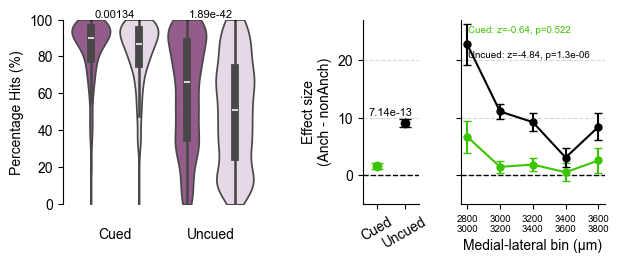

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Build long-form DataFrame for seaborn and mixed models
records = []
for _, row in gcs_.iterrows():
    for trial_type in ['b', 'nb']:
        for label in [0, 1]:
            col = f'pct_{trial_type}_{label}'
            if col not in row or pd.isna(row[col]):
                continue
            records.append({
                'pct_hits': row[col],
                'trial_type': trial_type,
                'label': label,
                'condition': f'{trial_type}, label={label}',
                'mouse': row.get('mouse', np.nan),
                'day': row.get('day', np.nan),
                'cluster_id': row.get('cluster_id', np.nan),
            })

df_plot = pd.DataFrame.from_records(records)

# Ensure categorical ordering: b,label=1; b,label=0; nb,label=1; nb,label=0
order = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

# Color mapping: label 0 -> #e7d7e8, label 1 -> #9d5391
palette = {
    'b, label=0':  '#e7d7e8',
    'b, label=1':  '#9d5391',
    'nb, label=0': '#e7d7e8',
    'nb, label=1': '#9d5391',
}

# Colors for Cued / Uncued
trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}

# ----- Mixed models for comparisons within beaconed and non-beaconed -----
p_b = np.nan
p_nb = np.nan
eff_b = np.nan
eff_nb = np.nan
se_b = np.nan
se_nb = np.nan

def fit_lmm_trialtype(df_subset, trial_label):
    df_mod = df_subset.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        print(f"{trial_label}: not enough data for both labels")
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={
                'day': '0 + C(day)',
                'cluster': '0 + C(cluster_id)',
            },
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{trial_label}: mixed model summary")
        print(m_fit.summary())

        term = 'C(label)[T.1]'
        pval = m_fit.pvalues.get(term, np.nan)
        effect = m_fit.params.get(term, np.nan)

        cov = m_fit.cov_params()
        if term in cov.index:
            se = np.sqrt(cov.loc[term, term])
        else:
            se = np.nan

        return pval, effect, se
    except Exception as e:
        print(f"\n{trial_label}: mixed model failed with error: {e}")
        return np.nan, np.nan, np.nan

# Beaconed only
df_b = df_plot[df_plot['trial_type'] == 'b']
p_b, eff_b, se_b = fit_lmm_trialtype(df_b, 'Beaconed')

# Non-beaconed only
df_nb = df_plot[df_plot['trial_type'] == 'nb']
p_nb, eff_nb, se_nb = fit_lmm_trialtype(df_nb, 'Non-beaconed')

# ----- Mixed model for interaction (difference of effect sizes) -----
df_inter = df_plot.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b', 'nb'])
try:
    md_inter = smf.mixedlm(
        'pct_hits ~ C(label) * C(trial_type)',
        df_inter,
        groups=df_inter['mouse'],
        vc_formula={
            'day': '0 + C(day)',
            'cluster': '0 + C(cluster_id)',
        },
    )
    m_fit_inter = md_inter.fit(reml=False, method='lbfgs')
    print("\nInteraction mixed model summary")
    print(m_fit_inter.summary())
    interaction_term = 'C(label)[T.1]:C(trial_type)[T.nb]'
    p_inter = m_fit_inter.pvalues.get(interaction_term, np.nan)
    eff_inter = m_fit_inter.params.get(interaction_term, np.nan)
except Exception as e:
    print(f"\nInteraction mixed model failed with error: {e}")
    p_inter = np.nan
    eff_inter = np.nan

# ----- Binned SC_x effect sizes for GCS cells -----
sc_bins = [(2800, 3000), (3000, 3200), (3200, 3400), (3400, 3600), (3600, 3800)]
sc_bin_labels = ['2800\n3000', '3000\n3200', '3200\n3400', '3400\n3600', '3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]
sc_offsets = {'Cued': 0, 'Uncued': 0}

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

gcs_plot = gcs_.copy()
if 'SC_x' in gcs_plot.columns:
    gcs_plot['SC_x'] = np.abs(gcs_plot['SC_x'])
else:
    gcs_plot['SC_x'] = np.abs(gcs_plot['coord_SCs_x'])
gcs_plot['delta_b']  = gcs_plot['pct_b_1'] - gcs_plot['pct_b_0']
gcs_plot['delta_nb'] = gcs_plot['pct_nb_1'] - gcs_plot['pct_nb_0']

# ----- SC_x LMM: interaction model on long-form data -----
def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    """Interaction LMM: pct_hits ~ C(label) * SC_x_scaled.

    Tests whether medial-lateral position (SC_x) modulates the anchoring effect
    (label=1 vs label=0). Uses 2 rows per cell (both labels), so cluster_id can
    be included as a VC — more principled than regressing pre-computed deltas.

    sc_x_lookup: DataFrame with columns [cluster_id, mouse, day, SC_x].
    Returns (z, p) for the interaction term C(label)[T.1]:SC_x_scaled.
    """
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id', 'mouse', 'day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id', 'SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0  # coefficient = change per 200 µm bin
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * SC_x_scaled',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{label_str}: SC_x interaction LMM summary")
        print(m_fit.summary())
        term = 'C(label)[T.1]:SC_x_scaled'
        return m_fit.tvalues.get(term, np.nan), m_fit.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan

sc_x_lookup = gcs_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, 'Cued SC_x')
z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, 'Uncued SC_x')

# ----- Figure: 4-column GridSpec with a spacer between col 0 and col 1 -----
fig = plt.figure(figsize=(7, 2.4))
gs = fig.add_gridspec(1, 4, width_ratios=[2.5, 0.2, 0.7, 1.8], wspace=0.4)
ax      = fig.add_subplot(gs[0])   # violin
ax_eff  = fig.add_subplot(gs[2])   # effect size (skip gs[1] spacer)
ax_bin  = fig.add_subplot(gs[3])   # binned SC_x

# Left: seaborn violin with annotations
sns.violinplot(
    data=df_plot,
    x='condition',
    y='pct_hits',
    order=order,
    palette=palette,
    inner='box',
    cut=0,
    ax=ax,
)

ax.set_ylabel('Percentage Hits (%)')
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('')
ax.set_title('')

# Add trial type labels between violins
y_label_pos = -20
ax.text(0.5, y_label_pos, 'Cued', ha='center', va='bottom', fontsize=10)
ax.text(2.5, y_label_pos, 'Uncued', ha='center', va='bottom', fontsize=10)

# Beaconed bracket (x=0,1)
x1_b, x2_b = 0, 1
bracket_y_b = 100
h_b = 3
ax.plot(
    [x1_b, x1_b, x2_b, x2_b],
    [bracket_y_b, bracket_y_b + h_b, bracket_y_b + h_b, bracket_y_b],
    color='k', linewidth=1.0,
)
ax.text(
    (x1_b + x2_b) / 2, 100,
    f"{p_b:.3g}" if not np.isnan(p_b) else "NA",
    ha='center', va='bottom', fontsize=8,
)

# Non-beaconed bracket (x=2,3)
x1_nb, x2_nb = 2, 3
bracket_y_nb = 100
h_nb = 3
ax.plot(
    [x1_nb, x1_nb, x2_nb, x2_nb],
    [bracket_y_nb, bracket_y_nb + h_nb, bracket_y_nb + h_nb, bracket_y_nb],
    color='k', linewidth=1.0,
)
ax.text(
    (x1_nb + x2_nb) / 2, 100,
    f"{p_nb:.3g}" if not np.isnan(p_nb) else "NA",
    ha='center', va='bottom', fontsize=8,
)

sns.despine(ax=ax, bottom=True)

# Middle: effect size errorbar — Cued and Uncued plotted separately with their colors
for xi, (eff, se, label) in enumerate([(eff_b, se_b, 'Cued'), (eff_nb, se_nb, 'Uncued')]):
    if not np.isnan(eff):
        ax_eff.errorbar(
            xi, eff,
            yerr=se if not np.isnan(se) else None,
            fmt='o',
            color=trial_colors[label],
            capsize=4,
        )

ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
ax_eff.set_xticks([0, 1])
ax_eff.set_xlim(-0.5, 1.5)
ax_eff.set_ylim(-5, 27)
ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
ax_eff.set_ylabel('Effect size\n(Anch - nonAnch)')
ax_eff.set_title('')
ax_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_eff)

if not np.isnan(p_inter):
    ax_eff.text(
        0.5, 10,
        f"{p_inter:.3g}",
        ha='center', va='bottom', fontsize=8
    )

# Right: binned effect size by SC_x position (GCS cells)
for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
    means, sems, xs = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        sub = gcs_plot[(gcs_plot['SC_x'] >= lo) & (gcs_plot['SC_x'] < hi)][delta_col].dropna()
        means.append(sub.mean())
        sems.append(_sem(sub))
        xs.append(center + sc_offsets[trial_label])
    ax_bin.errorbar(
        xs, means, yerr=sems,
        fmt='o-', color=trial_colors[trial_label],
        capsize=3, linewidth=1.5, markersize=5,
        label=trial_label,
    )

ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
ax_bin.set_xticks(sc_bin_centers)
ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
ax_bin.set_xlabel('Medial-lateral bin (µm)')
ax_bin.set_ylim(-5, 27)
ax_bin.set_yticklabels([])
ax_bin.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_bin)

# Annotate SC_x LMM z-statistic and p-value for each trial type
for i, (z_val, p_val, lbl) in enumerate(
        [(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
    if not np.isnan(z_val):
        ax_bin.text(
            0.05, 0.97 - i * 0.14,
            f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
            ha='left', va='top', fontsize=7,
            color=trial_colors[lbl],
            transform=ax_bin.transAxes,
        )

plt.tight_layout()
plt.savefig('correlation_of_task_anchoring_with_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()


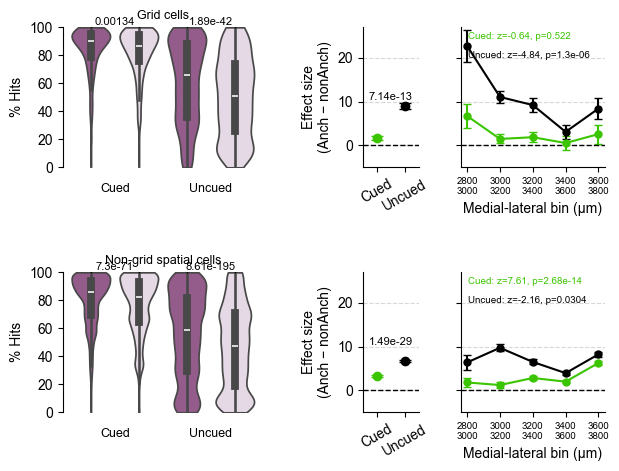

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
palette = {
    'b, label=0':  '#e7d7e8', 'b, label=1':  '#9d5391',
    'nb, label=0': '#e7d7e8', 'nb, label=1': '#9d5391',
}
trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}
sc_bins        = [(2800,3000),(3000,3200),(3200,3400),(3400,3600),(3600,3800)]
sc_bin_labels  = ['2800\n3000','3000\n3200','3200\n3400','3400\n3600','3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

def build_df_plot(src):
    records = []
    for _, row in src.iterrows():
        for trial_type in ['b', 'nb']:
            for label in [0, 1]:
                col = f'pct_{trial_type}_{label}'
                if col not in row or pd.isna(row[col]):
                    continue
                records.append({
                    'pct_hits': row[col], 'trial_type': trial_type, 'label': label,
                    'condition': f'{trial_type}, label={label}',
                    'mouse': row.get('mouse', np.nan), 'day': row.get('day', np.nan),
                    'cluster_id': row.get('cluster_id', np.nan),
                })
    df = pd.DataFrame.from_records(records)
    df['condition'] = pd.Categorical(df['condition'], categories=order, ordered=True)
    return df

def fit_lmm_trialtype(df_subset, trial_label):
    df_mod = df_subset.dropna(subset=['pct_hits','mouse','day','cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm('pct_hits ~ C(label)', df_mod, groups=df_mod['mouse'],
                         vc_formula={'day':'0+C(day)','cluster':'0+C(cluster_id)'})
        mf = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]'
        pval = mf.pvalues.get(term, np.nan)
        eff  = mf.params.get(term, np.nan)
        cov  = mf.cov_params()
        se   = np.sqrt(cov.loc[term,term]) if term in cov.index else np.nan
        return pval, eff, se
    except Exception as e:
        print(f"{trial_label}: LMM failed: {e}")
        return np.nan, np.nan, np.nan

def fit_inter_lmm(df_plot):
    df_inter = df_plot.dropna(subset=['pct_hits','mouse','day','cluster_id']).copy()
    df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b','nb'])
    try:
        md = smf.mixedlm('pct_hits ~ C(label)*C(trial_type)', df_inter,
                         groups=df_inter['mouse'],
                         vc_formula={'day':'0+C(day)','cluster':'0+C(cluster_id)'})
        mf = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]:C(trial_type)[T.nb]'
        return mf.pvalues.get(term, np.nan)
    except:
        return np.nan

def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id','mouse','day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits','mouse','day','cluster_id','SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm('pct_hits ~ C(label)*SC_x_scaled', df_mod,
                         groups=df_mod['mouse'],
                         vc_formula={'day':'0+C(day)','cluster':'0+C(cluster_id)'})
        mf = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]:SC_x_scaled'
        return mf.tvalues.get(term, np.nan), mf.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan

def draw_row(ax, ax_eff, ax_bin, src_df, row_title):
    df_plot = build_df_plot(src_df)

    p_b,  eff_b,  se_b  = fit_lmm_trialtype(df_plot[df_plot['trial_type']=='b'],  f'{row_title} Cued')
    p_nb, eff_nb, se_nb = fit_lmm_trialtype(df_plot[df_plot['trial_type']=='nb'], f'{row_title} Uncued')
    p_inter = fit_inter_lmm(df_plot)

    # --- violin ---
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('% Hits')
    ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.spines['bottom'].set_visible(False); ax.set_xlabel('')
    ax.set_title(row_title, fontsize=9)
    for xt, lbl in [(0.5,'Cued'),(2.5,'Uncued')]:
        ax.text(xt, -20, lbl, ha='center', va='bottom', fontsize=9)
    for x1, x2, pv in [(0,1,p_b),(2,3,p_nb)]:
        ax.plot([x1,x1,x2,x2],[100,103,103,100], color='k', lw=1)
        ax.text((x1+x2)/2, 100, f"{pv:.3g}" if not np.isnan(pv) else "NA",
                ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax, bottom=True)

    # --- effect size ---
    for xi, (eff, se, lbl) in enumerate([(eff_b,se_b,'Cued'),(eff_nb,se_nb,'Uncued')]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
    ax_eff.axhline(0, color='k', ls='--', lw=1)
    ax_eff.set_xticks([0,1]); ax_eff.set_xlim(-0.5,1.5); ax_eff.set_ylim(-5,27)
    ax_eff.set_xticklabels(['Cued','Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', ls='--', alpha=0.5)
    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax_eff)

    # --- binned SC_x ---
    cells_plot = src_df.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']
    sc_x_lookup = cells_plot[['cluster_id','mouse','day','SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type']=='b'],  sc_x_lookup, f'{row_title} Cued')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type']=='nb'], sc_x_lookup, f'{row_title} Uncued')
    for delta_col, trial_label in [('delta_b','Cued'),('delta_nb','Uncued')]:
        means, sems, xs = [], [], []
        for (lo,hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x']>=lo)&(cells_plot['SC_x']<hi)][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, lw=1.5, ms=5, label=trial_label)
    ax_bin.axhline(0, color='k', ls='--', lw=1)
    ax_bin.set_xticks(sc_bin_centers); ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5,27); ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', ls='--', alpha=0.5)
    for i, (z_val, p_val, lbl) in enumerate([(z_scx_b,p_scx_b,'Cued'),(z_scx_nb,p_scx_nb,'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(0.05, 0.97-i*0.14, f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                        ha='left', va='top', fontsize=7, color=trial_colors[lbl],
                        transform=ax_bin.transAxes)
    sns.despine(ax=ax_bin)

# ── 2-row figure ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 5))
gs  = fig.add_gridspec(2, 4, width_ratios=[2.5,0.2,0.7,1.8], wspace=0.4, hspace=0.75)

for row_idx, (src, title) in enumerate([(gcs_, 'Grid cells'), (ngs_, 'Non-grid spatial cells')]):
    ax     = fig.add_subplot(gs[row_idx, 0])
    ax_eff = fig.add_subplot(gs[row_idx, 2])
    ax_bin = fig.add_subplot(gs[row_idx, 3])
    draw_row(ax, ax_eff, ax_bin, src, title)

plt.savefig('correlation_task_anchoring_gcs_ngs.pdf', dpi=300, bbox_inches='tight')
plt.show()



Grid cells Cued SC_x: SC_x interaction LMM summary
                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     pct_hits  
No. Observations:      1335        Method:                 ML        
No. Groups:            8           Scale:                  91.6901   
Min. group size:       22          Log-Likelihood:         -5018.1999
Max. group size:       351         Converged:              Yes       
Mean group size:       166.9                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  69.316    8.519  8.136 0.000 52.619 86.013
C(label)[T.1]               6.722    7.894  0.851 0.395 -8.751 22.194
SC_x_scaled                 0.589    0.502  1.174 0.241 -0.395  1.574
C(label)[T.1]:SC_x_scaled  -0.305    0.477 -0.640 0.52

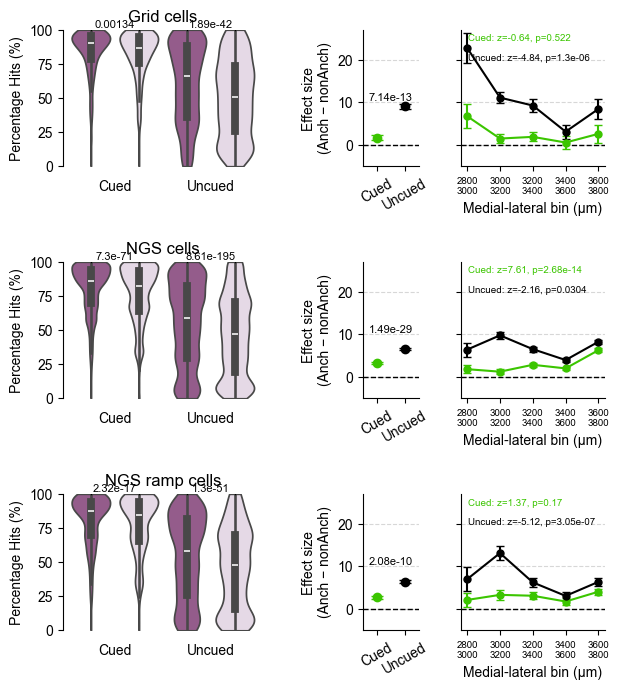

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}

sc_bins       = [(2800, 3000), (3000, 3200), (3200, 3400), (3400, 3600), (3600, 3800)]
sc_bin_labels = ['2800\n3000', '3000\n3200', '3200\n3400', '3400\n3600', '3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan


def build_records(df):
    records = []
    for _, row in df.iterrows():
        for trial_type in ['b', 'nb']:
            for label in [0, 1]:
                col = f'pct_{trial_type}_{label}'
                if col not in row or pd.isna(row[col]):
                    continue
                records.append({
                    'pct_hits': row[col],
                    'trial_type': trial_type,
                    'label': label,
                    'condition': f'{trial_type}, label={label}',
                    'mouse': row.get('mouse', np.nan),
                    'day': row.get('day', np.nan),
                    'cluster_id': row.get('cluster_id', np.nan),
                })
    return pd.DataFrame.from_records(records)


def fit_lmm(df_subset, label_str):
    df_mod = df_subset.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]'
        pval   = m_fit.pvalues.get(term, np.nan)
        effect = m_fit.params.get(term, np.nan)
        cov    = m_fit.cov_params()
        se     = np.sqrt(cov.loc[term, term]) if term in cov.index else np.nan
        return pval, effect, se
    except Exception as e:
        print(f"{label_str}: LMM failed: {e}")
        return np.nan, np.nan, np.nan


def fit_interaction_lmm(df_plot):
    df_inter = df_plot.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b', 'nb'])
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * C(trial_type)',
            df_inter,
            groups=df_inter['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        term = 'C(label)[T.1]:C(trial_type)[T.nb]'
        return m_fit.pvalues.get(term, np.nan), m_fit.params.get(term, np.nan)
    except Exception as e:
        print(f"Interaction LMM failed: {e}")
        return np.nan, np.nan


def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id', 'mouse', 'day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id', 'SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * SC_x_scaled',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{label_str}: SC_x interaction LMM summary")
        print(m_fit.summary())
        term = 'C(label)[T.1]:SC_x_scaled'
        return m_fit.tvalues.get(term, np.nan), m_fit.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan


def draw_three_panel(ax, ax_eff, ax_bin, df_cells, cell_label):
    order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
    palette = {
        'b, label=0':  '#e7d7e8',
        'b, label=1':  '#9d5391',
        'nb, label=0': '#e7d7e8',
        'nb, label=1': '#9d5391',
    }

    df_plot = build_records(df_cells)
    df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

    # LMMs
    p_b,  eff_b,  se_b  = fit_lmm(df_plot[df_plot['trial_type'] == 'b'],  f'{cell_label} Beaconed')
    p_nb, eff_nb, se_nb = fit_lmm(df_plot[df_plot['trial_type'] == 'nb'], f'{cell_label} Non-beaconed')
    p_inter, _          = fit_interaction_lmm(df_plot)

    # ── Violin ──────────────────────────────────────────────────────────
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('Percentage Hits (%)')
    ax.set_ylim(0, 100)
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)
    ax.set_xlabel('')
    ax.set_title(cell_label)

    y_label_pos = -20
    ax.text(0.5, y_label_pos, 'Cued',   ha='center', va='bottom', fontsize=10)
    ax.text(2.5, y_label_pos, 'Uncued', ha='center', va='bottom', fontsize=10)

    for x1, x2, p_val in [(0, 1, p_b), (2, 3, p_nb)]:
        ax.plot([x1, x1, x2, x2], [100, 103, 103, 100], color='k', linewidth=1.0)
        ax.text((x1 + x2) / 2, 100,
                f"{p_val:.3g}" if not np.isnan(p_val) else "NA",
                ha='center', va='bottom', fontsize=8)

    sns.despine(ax=ax, bottom=True)

    # ── Effect size errorbars ────────────────────────────────────────────
    for xi, (eff, se, lbl) in enumerate([(eff_b, se_b, 'Cued'), (eff_nb, se_nb, 'Uncued')]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
    ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_eff.set_xticks([0, 1])
    ax_eff.set_xlim(-0.5, 1.5)
    ax_eff.set_ylim(-5, 27)
    ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax_eff)

    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)

    # ── Binned SC_x errorbars ────────────────────────────────────────────
    cells_plot = df_cells.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']

    sc_x_lookup = cells_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, f'{cell_label} Cued SC_x')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, f'{cell_label} Uncued SC_x')

    for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
        means, sems, xs = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)][delta_col].dropna()
            means.append(sub.mean())
            sems.append(_sem(sub))
            xs.append(center)
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, linewidth=1.5, markersize=5, label=trial_label)

    ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_bin.set_xticks(sc_bin_centers)
    ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5, 27)
    ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=ax_bin)

    for i, (z_val, p_val, lbl) in enumerate(
            [(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(
                0.05, 0.97 - i * 0.14,
                f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                ha='left', va='top', fontsize=7,
                color=trial_colors[lbl],
                transform=ax_bin.transAxes,
            )


# ── Build figure: 3 rows (GCS / NGS / NGS-ramp), each with 4-column GridSpec ─
rows = [
    (gcs_,      'Grid cells'),
    (ngs_,      'NGS cells'),
    (ngs_ramp_, 'NGS ramp cells'),
]

fig = plt.figure(figsize=(7, 7.8))
gs = fig.add_gridspec(3, 4, width_ratios=[2.5, 0.2, 0.7, 1.8],
                      wspace=0.4, hspace=0.7)

for row, (df_cells, cell_label) in enumerate(rows):
    ax     = fig.add_subplot(gs[row, 0])
    ax_eff = fig.add_subplot(gs[row, 2])
    ax_bin = fig.add_subplot(gs[row, 3])
    draw_three_panel(ax, ax_eff, ax_bin, df_cells, cell_label)

plt.savefig('correlation_of_task_anchoring_gcs_ngs.pdf', dpi=300, bbox_inches='tight')
plt.show()



Grid cells Cued: SC_x interaction LMM summary
                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     pct_hits  
No. Observations:      1335        Method:                 ML        
No. Groups:            8           Scale:                  91.6901   
Min. group size:       22          Log-Likelihood:         -5018.1999
Max. group size:       351         Converged:              Yes       
Mean group size:       166.9                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  69.316    8.519  8.136 0.000 52.619 86.013
C(label)[T.1]               6.722    7.894  0.851 0.395 -8.751 22.194
SC_x_scaled                 0.589    0.502  1.174 0.241 -0.395  1.574
C(label)[T.1]:SC_x_scaled  -0.305    0.477 -0.640 0.522 -1.

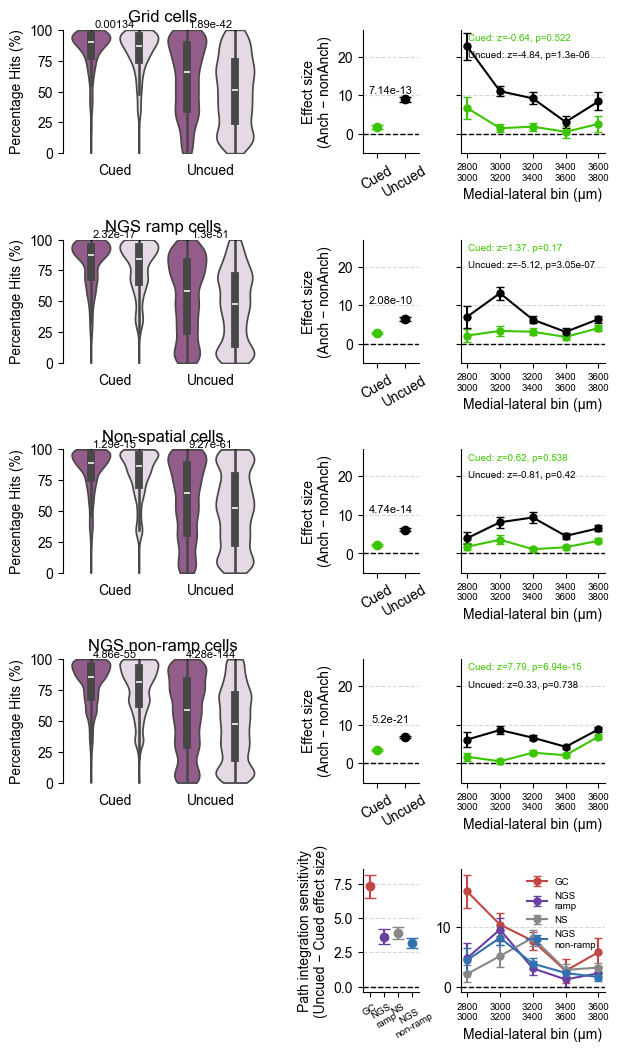

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Colors ────────────────────────────────────────────────────────────────────
gc_color       = '#c04744'
ramp_color     = '#6b3fa0'
ns_color       = '#888888'
nonramp_color  = '#3171ae'
trial_colors   = {'Cued': '#3bc500', 'Uncued': 'black'}

cell_colors = {
    'Grid cells':        gc_color,
    'NGS ramp cells':    ramp_color,
    'Non-spatial cells': ns_color,
    'NGS non-ramp cells': nonramp_color,
}
cell_short = {
    'Grid cells':        'GC',
    'NGS ramp cells':    'NGS\nramp',
    'Non-spatial cells': 'NS',
    'NGS non-ramp cells': 'NGS\nnon-ramp',
}
all_cell_labels = ['Grid cells', 'NGS ramp cells', 'Non-spatial cells', 'NGS non-ramp cells']


def draw_three_panel_returning(ax, ax_eff, ax_bin, df_cells, cell_label):
    """Draws violin / effect-size / ML-bin panels and returns LMM results +
    processed cells_plot DataFrame for downstream sensitivity row."""
    order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
    palette = {
        'b, label=0': '#e7d7e8', 'b, label=1': '#9d5391',
        'nb, label=0': '#e7d7e8', 'nb, label=1': '#9d5391',
    }

    df_plot = build_records(df_cells)
    df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

    p_b,  eff_b,  se_b  = fit_lmm(df_plot[df_plot['trial_type'] == 'b'],  f'{cell_label} Beaconed')
    p_nb, eff_nb, se_nb = fit_lmm(df_plot[df_plot['trial_type'] == 'nb'], f'{cell_label} Non-beaconed')
    p_inter, _          = fit_interaction_lmm(df_plot)

    # ── Violin ───────────────────────────────────────────────────────────
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('Percentage Hits (%)'); ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.spines['bottom'].set_visible(False); ax.set_xlabel('')
    ax.set_title(cell_label)
    for xt, lbl in [(0.5, 'Cued'), (2.5, 'Uncued')]:
        ax.text(xt, -20, lbl, ha='center', va='bottom', fontsize=10)
    for x1, x2, p_val in [(0, 1, p_b), (2, 3, p_nb)]:
        ax.plot([x1, x1, x2, x2], [100, 103, 103, 100], color='k', linewidth=1.0)
        ax.text((x1+x2)/2, 100, f"{p_val:.3g}" if not np.isnan(p_val) else "NA",
                ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax, bottom=True)

    # ── Effect size ──────────────────────────────────────────────────────
    for xi, (eff, se, lbl) in enumerate([(eff_b, se_b, 'Cued'), (eff_nb, se_nb, 'Uncued')]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
    ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_eff.set_xticks([0, 1]); ax_eff.set_xlim(-0.5, 1.5); ax_eff.set_ylim(-5, 27)
    ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', linestyle='--', alpha=0.5); sns.despine(ax=ax_eff)
    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)

    # ── ML bin ───────────────────────────────────────────────────────────
    cells_plot = df_cells.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']
    sc_x_lookup = cells_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, f'{cell_label} Cued')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, f'{cell_label} Uncued')
    for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
        means, sems, xs = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, linewidth=1.5, markersize=5, label=trial_label)
    ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_bin.set_xticks(sc_bin_centers); ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5, 27); ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', linestyle='--', alpha=0.5); sns.despine(ax=ax_bin)
    for i, (z_val, p_val, lbl) in enumerate([(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(0.05, 0.97-i*0.14, f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                        ha='left', va='top', fontsize=7, color=trial_colors[lbl],
                        transform=ax_bin.transAxes)

    return eff_b, se_b, eff_nb, se_nb, cells_plot


# ── Figure: 5 rows × 4 cols ───────────────────────────────────────────────────
# Row 0: Grid cells
# Row 1: NGS ramp cells
# Row 2: Non-spatial cells
# Row 3: NGS non-ramp cells
# Row 4: Sensitivity (all 4 cell types)

fig = plt.figure(figsize=(7, 12.5))
gs = fig.add_gridspec(5, 4, width_ratios=[2.5, 0.2, 0.7, 1.8],
                      wspace=0.4, hspace=0.7)

stored = {}
for row_idx, (df_cells, cell_label) in enumerate([
    (gcs_,         'Grid cells'),
    (ngs_ramp_,    'NGS ramp cells'),
    (others_,      'Non-spatial cells'),
    (ngs_nonramp_, 'NGS non-ramp cells'),
]):
    ax     = fig.add_subplot(gs[row_idx, 0])
    ax_eff = fig.add_subplot(gs[row_idx, 2])
    ax_bin = fig.add_subplot(gs[row_idx, 3])
    eff_b, se_b, eff_nb, se_nb, cells_plot = draw_three_panel_returning(
        ax, ax_eff, ax_bin, df_cells, cell_label,
    )
    stored[cell_label] = dict(eff_b=eff_b, se_b=se_b, eff_nb=eff_nb, se_nb=se_nb,
                              cells_plot=cells_plot)

# ── Row 4: Sensitivity = uncued effect − cued effect ─────────────────────────
fig.add_subplot(gs[4, 0]).axis('off')
fig.add_subplot(gs[4, 1]).axis('off')

ax_sens_eff = fig.add_subplot(gs[4, 2])
ax_sens_bin = fig.add_subplot(gs[4, 3])

# Overall sensitivity errorbars (one point per cell type)
for xi, cell_label in enumerate(all_cell_labels):
    d = stored[cell_label]
    eff_b, se_b, eff_nb, se_nb = d['eff_b'], d['se_b'], d['eff_nb'], d['se_nb']
    sens    = eff_nb - eff_b
    se_sens = np.sqrt(se_b**2 + se_nb**2) if not (np.isnan(se_b) or np.isnan(se_nb)) else np.nan
    if not np.isnan(sens):
        ax_sens_eff.errorbar(xi, sens, yerr=(se_sens if not np.isnan(se_sens) else None),
                             fmt='o', color=cell_colors[cell_label], capsize=4, markersize=6)

ax_sens_eff.axhline(0, color='k', linestyle='--', linewidth=1)
ax_sens_eff.set_xticks(range(len(all_cell_labels)))
ax_sens_eff.set_xlim(-0.5, len(all_cell_labels) - 0.5)
ax_sens_eff.set_xticklabels([cell_short[k] for k in all_cell_labels], fontsize=7, rotation=30)
ax_sens_eff.set_ylabel('Path integration sensitivity\n(Uncued − Cued effect size)')
ax_sens_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_sens_eff)

# ML-binned sensitivity: (delta_nb − delta_b) as a function of M-L position
for cell_label in all_cell_labels:
    color = cell_colors[cell_label]
    cells_plot = stored[cell_label]['cells_plot'].copy()
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']
    means, sems, xs = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
    ax_sens_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=color,
                         capsize=3, linewidth=1.5, markersize=5,
                         label=cell_short[cell_label])

ax_sens_bin.axhline(0, color='k', linestyle='--', linewidth=1)
ax_sens_bin.set_xticks(sc_bin_centers); ax_sens_bin.set_xticklabels(sc_bin_labels, fontsize=7)
ax_sens_bin.set_xlabel('Medial-lateral bin (µm)')
ax_sens_bin.legend(fontsize=7, frameon=False, loc='upper right')
ax_sens_bin.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_sens_bin)

plt.savefig('gc_vs_ngs_ramp_sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()



Grid cells Cued: SC_x interaction LMM summary
                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     pct_hits  
No. Observations:      1335        Method:                 ML        
No. Groups:            8           Scale:                  91.6901   
Min. group size:       22          Log-Likelihood:         -5018.1999
Max. group size:       351         Converged:              Yes       
Mean group size:       166.9                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  69.316    8.519  8.136 0.000 52.619 86.013
C(label)[T.1]               6.722    7.894  0.851 0.395 -8.751 22.194
SC_x_scaled                 0.589    0.502  1.174 0.241 -0.395  1.574
C(label)[T.1]:SC_x_scaled  -0.305    0.477 -0.640 0.522 -1.

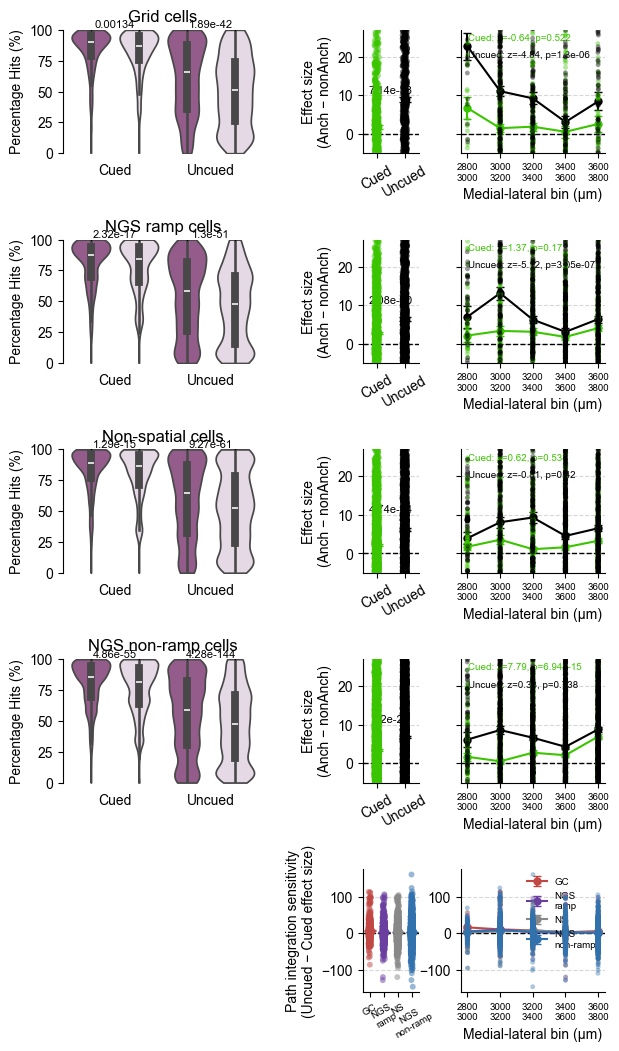

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Colors ────────────────────────────────────────────────────────────────────
gc_color       = '#c04744'
ramp_color     = '#6b3fa0'
ns_color       = '#888888'
nonramp_color  = '#3171ae'
trial_colors   = {'Cued': '#3bc500', 'Uncued': 'black'}

cell_colors = {
    'Grid cells':        gc_color,
    'NGS ramp cells':    ramp_color,
    'Non-spatial cells': ns_color,
    'NGS non-ramp cells': nonramp_color,
}
cell_short = {
    'Grid cells':        'GC',
    'NGS ramp cells':    'NGS\nramp',
    'Non-spatial cells': 'NS',
    'NGS non-ramp cells': 'NGS\nnon-ramp',
}
all_cell_labels = ['Grid cells', 'NGS ramp cells', 'Non-spatial cells', 'NGS non-ramp cells']

def draw_three_panel_returning(ax, ax_eff, ax_bin, df_cells, cell_label):
    """Draws violin / effect-size / ML-bin panels and returns LMM results +
    processed cells_plot DataFrame for downstream sensitivity row."""
    order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
    palette = {
        'b, label=0': '#e7d7e8', 'b, label=1': '#9d5391',
        'nb, label=0': '#e7d7e8', 'nb, label=1': '#9d5391',
    }

    df_plot = build_records(df_cells)
    df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

    p_b,  eff_b,  se_b  = fit_lmm(df_plot[df_plot['trial_type'] == 'b'],  f'{cell_label} Beaconed')
    p_nb, eff_nb, se_nb = fit_lmm(df_plot[df_plot['trial_type'] == 'nb'], f'{cell_label} Non-beaconed')
    p_inter, _          = fit_interaction_lmm(df_plot)

    # ── Violin ───────────────────────────────────────────────────────────
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('Percentage Hits (%)'); ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.spines['bottom'].set_visible(False); ax.set_xlabel('')
    ax.set_title(cell_label)
    for xt, lbl in [(0.5, 'Cued'), (2.5, 'Uncued')]:
        ax.text(xt, -20, lbl, ha='center', va='bottom', fontsize=10)
    for x1, x2, p_val in [(0, 1, p_b), (2, 3, p_nb)]:
        ax.plot([x1, x1, x2, x2], [100, 103, 103, 100], color='k', linewidth=1.0)
        ax.text((x1+x2)/2, 100, f"{p_val:.3g}" if not np.isnan(p_val) else "NA",
                ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax, bottom=True)

    # ── Effect size ──────────────────────────────────────────────────────
    # Use precomputed delta_b and delta_nb for scatter
    cells_plot = df_cells.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']

    for xi, (eff, se, lbl, col) in enumerate([
        (eff_b, se_b, 'Cued', 'delta_b'),
        (eff_nb, se_nb, 'Uncued', 'delta_nb')
    ]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
            # Add individual points (effect size per cell)
            vals = cells_plot[col].dropna()
            ax_eff.scatter(np.full_like(vals, xi, dtype=float) + np.random.uniform(-0.08, 0.08, size=len(vals)),
                           vals, color=trial_colors[lbl], alpha=0.5, s=18, zorder=10, edgecolor='none')
    ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_eff.set_xticks([0, 1]); ax_eff.set_xlim(-0.5, 1.5); ax_eff.set_ylim(-5, 27)
    ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', linestyle='--', alpha=0.5); sns.despine(ax=ax_eff)
    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)

    # ── ML bin ───────────────────────────────────────────────────────────
    sc_x_lookup = cells_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, f'{cell_label} Cued')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, f'{cell_label} Uncued')
    for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
        means, sems, xs = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
            # Add individual points for this bin
            ax_bin.scatter(np.full_like(sub, center, dtype=float) + np.random.uniform(-2, 2, size=len(sub)),
                           sub, color=trial_colors[trial_label], alpha=0.4, s=12, zorder=10, edgecolor='none')
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, linewidth=1.5, markersize=5, label=trial_label)
    ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_bin.set_xticks(sc_bin_centers); ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5, 27); ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', linestyle='--', alpha=0.5); sns.despine(ax=ax_bin)
    for i, (z_val, p_val, lbl) in enumerate([(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(0.05, 0.97-i*0.14, f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                        ha='left', va='top', fontsize=7, color=trial_colors[lbl],
                        transform=ax_bin.transAxes)

    return eff_b, se_b, eff_nb, se_nb, cells_plot

# ── Figure: 5 rows × 4 cols ───────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 12.5))
gs = fig.add_gridspec(5, 4, width_ratios=[2.5, 0.2, 0.7, 1.8],
                      wspace=0.4, hspace=0.7)

stored = {}
for row_idx, (df_cells, cell_label) in enumerate([
    (gcs_,         'Grid cells'),
    (ngs_ramp_,    'NGS ramp cells'),
    (others_,      'Non-spatial cells'),
    (ngs_nonramp_, 'NGS non-ramp cells'),
]):
    ax     = fig.add_subplot(gs[row_idx, 0])
    ax_eff = fig.add_subplot(gs[row_idx, 2])
    ax_bin = fig.add_subplot(gs[row_idx, 3])
    eff_b, se_b, eff_nb, se_nb, cells_plot = draw_three_panel_returning(
        ax, ax_eff, ax_bin, df_cells, cell_label,
    )
    stored[cell_label] = dict(eff_b=eff_b, se_b=se_b, eff_nb=eff_nb, se_nb=se_nb,
                              cells_plot=cells_plot)

# ── Row 4: Sensitivity = uncued effect − cued effect ─────────────────────────
fig.add_subplot(gs[4, 0]).axis('off')
fig.add_subplot(gs[4, 1]).axis('off')

ax_sens_eff = fig.add_subplot(gs[4, 2])
ax_sens_bin = fig.add_subplot(gs[4, 3])

# Overall sensitivity errorbars (one point per cell type) + individual points
for xi, cell_label in enumerate(all_cell_labels):
    d = stored[cell_label]
    eff_b, se_b, eff_nb, se_nb = d['eff_b'], d['se_b'], d['eff_nb'], d['se_nb']
    sens    = eff_nb - eff_b
    se_sens = np.sqrt(se_b**2 + se_nb**2) if not (np.isnan(se_b) or np.isnan(se_nb)) else np.nan
    if not np.isnan(sens):
        ax_sens_eff.errorbar(xi, sens, yerr=(se_sens if not np.isnan(se_sens) else None),
                             fmt='o', color=cell_colors[cell_label], capsize=4, markersize=6)
        # Add individual points (sensitivity per cell)
        cells_plot = d['cells_plot']
        vals = cells_plot['delta_nb'] - cells_plot['delta_b']
        vals = vals.dropna()
        ax_sens_eff.scatter(np.full_like(vals, xi, dtype=float) + np.random.uniform(-0.08, 0.08, size=len(vals)),
                            vals, color=cell_colors[cell_label], alpha=0.5, s=18, zorder=10, edgecolor='none')

ax_sens_eff.axhline(0, color='k', linestyle='--', linewidth=1)
ax_sens_eff.set_xticks(range(len(all_cell_labels)))
ax_sens_eff.set_xlim(-0.5, len(all_cell_labels) - 0.5)
ax_sens_eff.set_xticklabels([cell_short[k] for k in all_cell_labels], fontsize=7, rotation=30)
ax_sens_eff.set_ylabel('Path integration sensitivity\n(Uncued − Cued effect size)')
ax_sens_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_sens_eff)

# ML-binned sensitivity: (delta_nb − delta_b) as a function of M-L position + individual points
for cell_label in all_cell_labels:
    color = cell_colors[cell_label]
    cells_plot = stored[cell_label]['cells_plot'].copy()
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']
    means, sems, xs = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
        # Add individual points for this bin
        ax_sens_bin.scatter(np.full_like(sub, center, dtype=float) + np.random.uniform(-2, 2, size=len(sub)),
                            sub, color=color, alpha=0.4, s=12, zorder=10, edgecolor='none')
    ax_sens_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=color,
                         capsize=3, linewidth=1.5, markersize=5,
                         label=cell_short[cell_label])

ax_sens_bin.axhline(0, color='k', linestyle='--', linewidth=1)
ax_sens_bin.set_xticks(sc_bin_centers); ax_sens_bin.set_xticklabels(sc_bin_labels, fontsize=7)
ax_sens_bin.set_xlabel('Medial-lateral bin (µm)')
ax_sens_bin.legend(fontsize=7, frameon=False, loc='upper right')
ax_sens_bin.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_sens_bin)

plt.savefig('gc_vs_ngs_ramp_sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ── Helper: filter shuffled_ to the same cells as a given cell-type DataFrame ─
def _get_shuffled_for(df_cells, shuffled_all):
    keys = df_cells[['mouse', 'day', 'cluster_id']].drop_duplicates()
    return shuffled_all.merge(keys, on=['mouse', 'day', 'cluster_id'], how='inner').reset_index(drop=True)


def draw_three_panel_with_shuffle(ax, ax_eff, ax_bin, df_cells, cell_label, df_shuf=None):
    """Violin / effect-size / ML-bin panels with optional shuffled overlay (hollow markers)."""
    order   = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
    palette = {
        'b, label=0': '#e7d7e8', 'b, label=1': '#9d5391',
        'nb, label=0': '#e7d7e8', 'nb, label=1': '#9d5391',
    }

    df_plot = build_records(df_cells)
    df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

    p_b,  eff_b,  se_b  = fit_lmm(df_plot[df_plot['trial_type'] == 'b'],  f'{cell_label} Beaconed')
    p_nb, eff_nb, se_nb = fit_lmm(df_plot[df_plot['trial_type'] == 'nb'], f'{cell_label} Non-beaconed')
    p_inter, _          = fit_interaction_lmm(df_plot)

    # ── Violin ───────────────────────────────────────────────────────────
    sns.violinplot(data=df_plot, x='condition', y='pct_hits', order=order,
                   palette=palette, inner='box', cut=0, ax=ax)
    ax.set_ylabel('Percentage Hits (%)'); ax.set_ylim(0, 100)
    ax.set_xticks([]); ax.spines['bottom'].set_visible(False); ax.set_xlabel('')
    ax.set_title(cell_label)
    for xt, lbl in [(0.5, 'Cued'), (2.5, 'Uncued')]:
        ax.text(xt, -20, lbl, ha='center', va='bottom', fontsize=10)
    for x1, x2, p_val in [(0, 1, p_b), (2, 3, p_nb)]:
        ax.plot([x1, x1, x2, x2], [100, 103, 103, 100], color='k', linewidth=1.0)
        ax.text((x1+x2)/2, 100, f"{p_val:.3g}" if not np.isnan(p_val) else "NA",
                ha='center', va='bottom', fontsize=8)
    sns.despine(ax=ax, bottom=True)

    # ── Precompute cells_plot ─────────────────────────────────────────────
    cells_plot = df_cells.copy()
    cells_plot['SC_x'] = np.abs(cells_plot['SC_x']) if 'SC_x' in cells_plot.columns \
                         else np.abs(cells_plot['coord_SCs_x'])
    cells_plot['delta_b']  = cells_plot['pct_b_1'] - cells_plot['pct_b_0']
    cells_plot['delta_nb'] = cells_plot['pct_nb_1'] - cells_plot['pct_nb_0']

    # Precompute shuffled cells_plot (same SC_x lookup)
    shuf_plot = None
    shuf_eff_b = shuf_se_b = shuf_eff_nb = shuf_se_nb = np.nan
    if df_shuf is not None and len(df_shuf) > 0:
        shuf_plot = df_shuf.copy()
        shuf_plot['SC_x'] = np.abs(shuf_plot['SC_x']) if 'SC_x' in shuf_plot.columns \
                            else np.abs(shuf_plot['coord_SCs_x'])
        shuf_plot['delta_b']  = shuf_plot['pct_b_1'] - shuf_plot['pct_b_0']
        shuf_plot['delta_nb'] = shuf_plot['pct_nb_1'] - shuf_plot['pct_nb_0']
        df_shuf_records = build_records(df_shuf)
        df_shuf_records['condition'] = pd.Categorical(df_shuf_records['condition'], categories=order, ordered=True)
        _, shuf_eff_b,  shuf_se_b  = fit_lmm(df_shuf_records[df_shuf_records['trial_type'] == 'b'],  f'{cell_label} Shuf B')
        _, shuf_eff_nb, shuf_se_nb = fit_lmm(df_shuf_records[df_shuf_records['trial_type'] == 'nb'], f'{cell_label} Shuf NB')

    # ── Effect size ──────────────────────────────────────────────────────
    # Real data (filled markers)
    for xi, (eff, se, lbl, col) in enumerate([
        (eff_b, se_b, 'Cued', 'delta_b'),
        (eff_nb, se_nb, 'Uncued', 'delta_nb'),
    ]):
        if not np.isnan(eff):
            ax_eff.errorbar(xi, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=trial_colors[lbl], capsize=4)
            vals = cells_plot[col].dropna()
            ax_eff.scatter(np.full_like(vals, xi, dtype=float) + np.random.uniform(-0.08, 0.08, size=len(vals)),
                           vals, color=trial_colors[lbl], alpha=0.5, s=18, zorder=10, edgecolor='none')

    # Shuffled data (hollow markers, offset +0.18)
    if shuf_plot is not None:
        for xi, (s_eff, s_se, lbl, col) in enumerate([
            (shuf_eff_b, shuf_se_b, 'Cued', 'delta_b'),
            (shuf_eff_nb, shuf_se_nb, 'Uncued', 'delta_nb'),
        ]):
            if not np.isnan(s_eff):
                ax_eff.errorbar(xi + 0.18, s_eff,
                                yerr=(s_se if not np.isnan(s_se) else None),
                                fmt='o', color=trial_colors[lbl], capsize=4,
                                mfc='none', mec=trial_colors[lbl])
                vals = shuf_plot[col].dropna()
                ax_eff.scatter(np.full_like(vals, xi + 0.18, dtype=float) + np.random.uniform(-0.08, 0.08, size=len(vals)),
                               vals, facecolors='none', edgecolors=trial_colors[lbl],
                               alpha=0.5, s=18, zorder=10, linewidths=0.7)

    ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_eff.set_xticks([0.09, 1.09]); ax_eff.set_xlim(-0.5, 1.7); ax_eff.set_ylim(-5, 27)
    ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
    ax_eff.set_ylabel('Effect size\n(Anch − nonAnch)')
    ax_eff.grid(axis='y', linestyle='--', alpha=0.5); sns.despine(ax=ax_eff)
    if not np.isnan(p_inter):
        ax_eff.text(0.5, 10, f"{p_inter:.3g}", ha='center', va='bottom', fontsize=8)

    # ── ML bin ───────────────────────────────────────────────────────────
    sc_x_lookup = cells_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
    z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, f'{cell_label} Cued')
    z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, f'{cell_label} Uncued')

    # Real data
    for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
        means, sems, xs = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
            ax_bin.scatter(np.full_like(sub, center, dtype=float) + np.random.uniform(-2, 2, size=len(sub)),
                           sub, color=trial_colors[trial_label], alpha=0.4, s=12, zorder=10, edgecolor='none')
        ax_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=trial_colors[trial_label],
                        capsize=3, linewidth=1.5, markersize=5, label=trial_label)

    # Shuffled data (hollow markers, dashed lines)
    if shuf_plot is not None:
        for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
            s_means, s_sems, s_xs = [], [], []
            for (lo, hi), center in zip(sc_bins, sc_bin_centers):
                sub = shuf_plot[(shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)][delta_col].dropna()
                s_means.append(sub.mean()); s_sems.append(_sem(sub)); s_xs.append(center)
            ax_bin.errorbar(s_xs, s_means, yerr=s_sems, fmt='o--',
                            color=trial_colors[trial_label], capsize=3,
                            linewidth=1.0, markersize=5,
                            mfc='none', mec=trial_colors[trial_label])

    ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_bin.set_xticks(sc_bin_centers); ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bin.set_xlabel('Medial-lateral bin (µm)')
    ax_bin.set_ylim(-5, 27); ax_bin.set_yticklabels([])
    ax_bin.grid(axis='y', linestyle='--', alpha=0.5); sns.despine(ax=ax_bin)
    for i, (z_val, p_val, lbl) in enumerate([(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
        if not np.isnan(z_val):
            ax_bin.text(0.05, 0.97-i*0.14, f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
                        ha='left', va='top', fontsize=7, color=trial_colors[lbl],
                        transform=ax_bin.transAxes)

    return eff_b, se_b, eff_nb, se_nb, cells_plot, shuf_plot


# ── Figure: 5 rows × 4 cols ───────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 12.5))
gs = fig.add_gridspec(5, 4, width_ratios=[2.5, 0.2, 0.7, 1.8],
                      wspace=0.4, hspace=0.7)

stored_shuf = {}
cell_type_dfs = [
    (gcs_,         'Grid cells'),
    (ngs_ramp_,    'NGS ramp cells'),
    (others_,      'Non-spatial cells'),
    (ngs_nonramp_, 'NGS non-ramp cells'),
]

for row_idx, (df_cells, cell_label) in enumerate(cell_type_dfs):
    ax     = fig.add_subplot(gs[row_idx, 0])
    ax_eff = fig.add_subplot(gs[row_idx, 2])
    ax_bin = fig.add_subplot(gs[row_idx, 3])

    # match shuffled cells to this cell type
    df_shuf = _get_shuffled_for(df_cells, shuffled_) if 'shuffled_' in dir() and len(shuffled_) > 0 else None

    eff_b, se_b, eff_nb, se_nb, cells_plot, shuf_plot = draw_three_panel_with_shuffle(
        ax, ax_eff, ax_bin, df_cells, cell_label, df_shuf=df_shuf,
    )
    stored_shuf[cell_label] = dict(eff_b=eff_b, se_b=se_b, eff_nb=eff_nb, se_nb=se_nb,
                                   cells_plot=cells_plot, shuf_plot=shuf_plot)

# ── Row 4: Sensitivity = uncued effect − cued effect ─────────────────────────
fig.add_subplot(gs[4, 0]).axis('off')
fig.add_subplot(gs[4, 1]).axis('off')

ax_sens_eff = fig.add_subplot(gs[4, 2])
ax_sens_bin = fig.add_subplot(gs[4, 3])

for xi, cell_label in enumerate(all_cell_labels):
    d = stored_shuf[cell_label]
    eff_b, se_b, eff_nb, se_nb = d['eff_b'], d['se_b'], d['eff_nb'], d['se_nb']
    sens    = eff_nb - eff_b
    se_sens = np.sqrt(se_b**2 + se_nb**2) if not (np.isnan(se_b) or np.isnan(se_nb)) else np.nan
    color   = cell_colors[cell_label]

    # Real data (filled)
    if not np.isnan(sens):
        ax_sens_eff.errorbar(xi, sens, yerr=(se_sens if not np.isnan(se_sens) else None),
                             fmt='o', color=color, capsize=4, markersize=6)
        vals = d['cells_plot']['delta_nb'] - d['cells_plot']['delta_b']
        vals = vals.dropna()
        ax_sens_eff.scatter(np.full_like(vals, xi, dtype=float) + np.random.uniform(-0.08, 0.08, size=len(vals)),
                            vals, color=color, alpha=0.5, s=18, zorder=10, edgecolor='none')

    # Shuffled data (hollow, offset +0.2)
    if d['shuf_plot'] is not None:
        sp = d['shuf_plot']
        shuf_vals = sp['delta_nb'] - sp['delta_b']
        shuf_vals = shuf_vals.dropna()
        shuf_sens = shuf_vals.mean()
        shuf_se   = shuf_vals.sem()
        if not np.isnan(shuf_sens):
            ax_sens_eff.errorbar(xi + 0.2, shuf_sens, yerr=shuf_se,
                                 fmt='o', color=color, capsize=4, markersize=6,
                                 mfc='none', mec=color)
            ax_sens_eff.scatter(np.full_like(shuf_vals, xi + 0.2, dtype=float) + np.random.uniform(-0.08, 0.08, size=len(shuf_vals)),
                                shuf_vals, facecolors='none', edgecolors=color,
                                alpha=0.5, s=18, zorder=10, linewidths=0.7)

ax_sens_eff.axhline(0, color='k', linestyle='--', linewidth=1)
ax_sens_eff.set_xticks([xi + 0.1 for xi in range(len(all_cell_labels))])
ax_sens_eff.set_xlim(-0.5, len(all_cell_labels) - 0.3)
ax_sens_eff.set_xticklabels([cell_short[k] for k in all_cell_labels], fontsize=7, rotation=30)
ax_sens_eff.set_ylabel('Path integration sensitivity\n(Uncued − Cued effect size)')
ax_sens_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_sens_eff)

# ML-binned sensitivity (real = solid, shuffled = dashed hollow)
for cell_label in all_cell_labels:
    color      = cell_colors[cell_label]
    cells_plot = stored_shuf[cell_label]['cells_plot'].copy()
    shuf_plot  = stored_shuf[cell_label]['shuf_plot']
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']

    means, sems, xs = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        sub = cells_plot[(cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs.append(center)
        ax_sens_bin.scatter(np.full_like(sub, center, dtype=float) + np.random.uniform(-2, 2, size=len(sub)),
                            sub, color=color, alpha=0.4, s=12, zorder=10, edgecolor='none')
    ax_sens_bin.errorbar(xs, means, yerr=sems, fmt='o-', color=color,
                         capsize=3, linewidth=1.5, markersize=5,
                         label=cell_short[cell_label])

    if shuf_plot is not None:
        shuf_plot = shuf_plot.copy()
        shuf_plot['sensitivity'] = shuf_plot['delta_nb'] - shuf_plot['delta_b']
        s_means, s_sems, s_xs = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            sub = shuf_plot[(shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)]['sensitivity'].dropna()
            s_means.append(sub.mean()); s_sems.append(_sem(sub)); s_xs.append(center)
        ax_sens_bin.errorbar(s_xs, s_means, yerr=s_sems, fmt='o--',
                             color=color, capsize=3, linewidth=1.0, markersize=5,
                             mfc='none', mec=color)

ax_sens_bin.axhline(0, color='k', linestyle='--', linewidth=1)
ax_sens_bin.set_xticks(sc_bin_centers); ax_sens_bin.set_xticklabels(sc_bin_labels, fontsize=7)
ax_sens_bin.set_xlabel('Medial-lateral bin (µm)')
ax_sens_bin.legend(fontsize=7, frameon=False, loc='upper right')
ax_sens_bin.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_sens_bin)

plt.savefig('gc_vs_ngs_ramp_sensitivity_with_shuffle.pdf', dpi=300, bbox_inches='tight')
plt.show()
